In [ ]:
# Celda 1: Montar Google Drive e importar librerías
from google.colab import drive
drive.mount('/content/drive')

!pip install pyspark -q

# Celda 2: Inicializar Spark
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, mean, round, isnan, count
from pyspark.sql.types import IntegerType, FloatType, StringType
import pandas as pd

spark = SparkSession.builder.appName("TitanicETL").getOrCreate()

# Celda 3: Cargar datos
# Opción 1: Desde Google Drive
df = spark.read.csv("/content/drive/MyDrive/titanic.csv", header=True, inferSchema=True)

# Opción 2: Desde URL directa (si tienes acceso)
# df = spark.read.csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv", header=True, inferSchema=True)

print(f"Registros cargados: {df.count()}")
df.printSchema()
df.show(5)

# Celda 4: Pipeline ETL completo
# 4.1 Limpieza de nulos
df_clean = df.dropna(subset=["Survived", "Pclass", "Sex", "Age"])

# 4.2 Imputar edad faltante (si aún hay nulos)
avg_age = df_clean.select(mean("Age")).collect()[0][0]
df_clean = df_clean.fillna({"Age": avg_age})

# 4.3 Eliminar columnas no necesarias
df_clean = df_clean.drop("PassengerId", "Ticket", "Cabin", "Name")

# 4.4 Convertir tipos de datos
df_clean = df_clean.withColumn("Age", col("Age").cast(IntegerType()))
df_clean = df_clean.withColumn("Fare", col("Fare").cast(FloatType()))

# 4.5 Crear variables derivadas
from pyspark.sql.functions import when, col, lit

df_final = df_clean.withColumn(
    "AgeGroup",
    when(col("Age") < 18, "Child")
    .when(col("Age") < 30, "Young_Adult")
    .when(col("Age") < 50, "Adult")
    .otherwise("Senior")
)

df_final = df_final.withColumn(
    "FamilySize",
    col("SibSp") + col("Parch") + 1
)

df_final = df_final.withColumn(
    "IsAlone",
    when(col("FamilySize") == 1, 1).otherwise(0)
)

# 4.6 Codificar variables categóricas
from pyspark.ml.feature import StringIndexer

indexer_sex = StringIndexer(inputCol="Sex", outputCol="SexIndex", handleInvalid="keep")
indexer_embarked = StringIndexer(inputCol="Embarked", outputCol="EmbarkedIndex", handleInvalid="keep")
indexer_agegroup = StringIndexer(inputCol="AgeGroup", outputCol="AgeGroupIndex", handleInvalid="keep")

df_final = indexer_sex.fit(df_final).transform(df_final)
df_final = indexer_embarked.fit(df_final).transform(df_final)
df_final = indexer_agegroup.fit(df_final).transform(df_final)

# Celda 5: Guardar datos procesados
df_final.write.mode("overwrite").parquet("/content/drive/MyDrive/titanic_clean.parquet")

# Celda 6: Verificar resultado
print("Datos finales:")
df_final.show(5)
df_final.printSchema()

# Celda 7: Estadísticas básicas
print(f"Total registros: {df_final.count()}")
print(f"Columnas: {df_final.columns}")
df_final.describe(["Age", "Fare", "SibSp", "Parch"]).show()

Mounted at /content/drive
Registros cargados: 891
root
 |-- PassengerId: integer (nullable = true)
 |-- Survived: integer (nullable = true)
 |-- Pclass: integer (nullable = true)
 |-- Name: string (nullable = true)
 |-- Sex: string (nullable = true)
 |-- Age: double (nullable = true)
 |-- SibSp: integer (nullable = true)
 |-- Parch: integer (nullable = true)
 |-- Ticket: string (nullable = true)
 |-- Fare: double (nullable = true)
 |-- Cabin: string (nullable = true)
 |-- Embarked: string (nullable = true)

+-----------+--------+------+--------------------+------+----+-----+-----+----------------+-------+-----+--------+
|PassengerId|Survived|Pclass|                Name|   Sex| Age|SibSp|Parch|          Ticket|   Fare|Cabin|Embarked|
+-----------+--------+------+--------------------+------+----+-----+-----+----------------+-------+-----+--------+
|          1|       0|     3|Braund, Mr. Owen ...|  male|22.0|    1|    0|       A/5 21171|   7.25| NULL|       S|
|          2|       1|     

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📥 Cargando datos limpios desde Drive...
✅ Datos cargados: 891 registros
Columnas: ['Pclass', 'Sex_Code', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Code', 'AgeGroup_Code', 'FamilySize', 'IsAlone', 'Survived']

Train: 712 registros
Test: 179 registros

🤖 Entrenando modelos...
✅ Random Forest: AUC = 0.846, Accuracy = 81.56%
✅ Gradient Boosting: AUC = 0.798, Accuracy = 80.45%
✅ Logistic Regression: AUC = 0.848, Accuracy = 83.80%

📊 COMPARATIVO DE MODELOS:
                     accuracy  precision  recall     f1    auc
Random Forest           0.816      0.800   0.696  0.744  0.846
Gradient Boosting       0.804      0.793   0.667  0.724  0.798
Logistic Regression     0.838      0.845   0.710  0.772  0.848

🏆 MEJOR MODELO: LogisticRegression
Precisión: 83.80%
AUC-ROC: 0.848

Reporte de clasificación:
              precision    recall  f1-score   support

           

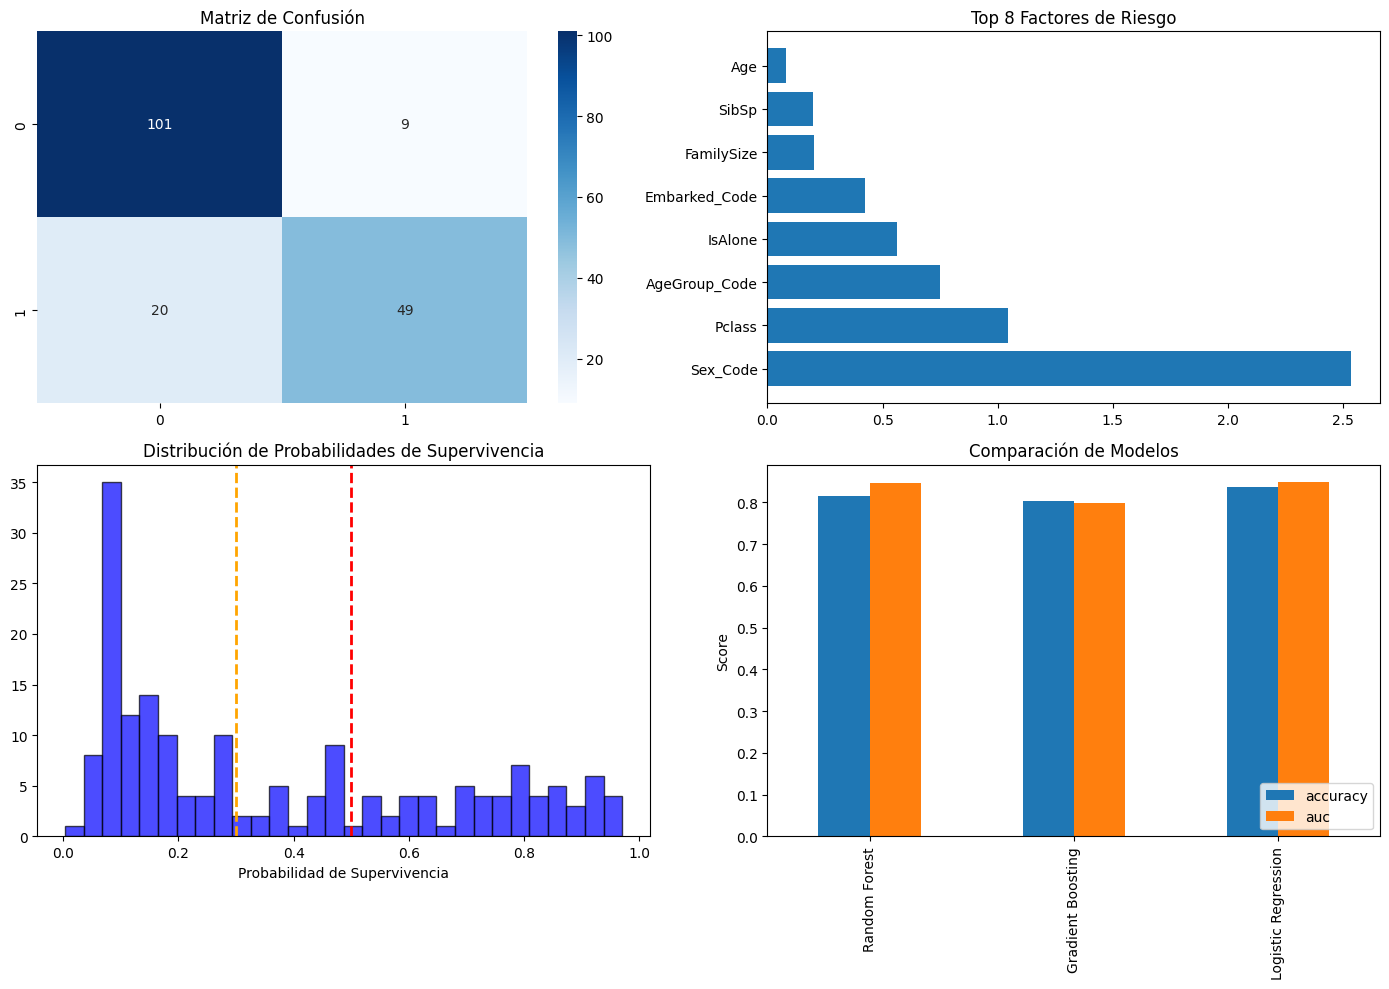


✅ Gráficos guardados en Drive
🎉 MODELO ML COMPLETADO


In [2]:
# ============================================================
# COLAB 2: MODELO ML - TITANIC + KPIs
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, roc_auc_score,
                            confusion_matrix, accuracy_score,
                            precision_score, recall_score, f1_score)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CARGAR DATOS LIMPIOS
print("📥 Cargando datos limpios desde Drive...")
df = pd.read_csv('/content/drive/MyDrive/titanicBigdata/titanic_for_ml.csv')

print(f"✅ Datos cargados: {len(df)} registros")
print(f"Columnas: {df.columns.tolist()}")

# 2. PREPARAR DATA
X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain: {len(X_train)} registros")
print(f"Test: {len(X_test)} registros")

# 3. ENTRENAR MÚLTIPLES MODELOS
print("\n🤖 Entrenando modelos...")

models = {
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

results = {}
best_model = None
best_auc = 0

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_proba)
    acc = accuracy_score(y_test, y_pred)

    results[name] = {
        'accuracy': acc,
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'auc': auc
    }

    if auc > best_auc:
        best_auc = auc
        best_model = model

    print(f"✅ {name}: AUC = {auc:.3f}, Accuracy = {acc:.2%}")

# 4. RESULTADOS COMPARATIVOS
results_df = pd.DataFrame(results).T
print("\n📊 COMPARATIVO DE MODELOS:")
print(results_df.round(3))

# 5. MEJOR MODELO (Random Forest)
model = best_model
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("\n🏆 MEJOR MODELO:", type(model).__name__)
print(f"Precisión: {accuracy_score(y_test, y_pred):.2%}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.3f}")

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

# 6. FACTORES MÁS IMPORTANTES
if hasattr(model, 'feature_importances_'):
    importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False)
elif hasattr(model, 'coef_'):
    # For logistic regression, use coefficients as importance
    # Take absolute value as coefficients can be negative (inverse relationship)
    importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': np.abs(model.coef_[0])
    }).sort_values('Importance', ascending=False)
else:
    print("Cannot determine feature importance for this model type.")
    importance = pd.DataFrame(columns=['Feature', 'Importance'])

print("\n⭐ TOP 5 FACTORES DE RIESGO:")
if not importance.empty:
    for i, row in importance.head(5).iterrows():
        print(f"  {row['Feature']}: {row['Importance']:.2%}")
else:
    print("  No feature importance available.")

# 7. KPIs DE NEGOCIO
print("\n📊 KPIs DE NEGOCIO:")

# KPI 1: Tasa de supervivencia actual
survival_rate = y.mean()
print(f"  • Tasa de supervivencia actual: {survival_rate:.2%}")

# KPI 2: Tasa predicha
pred_survival_rate = y_pred.mean()
print(f"  • Tasa de supervivencia predicha: {pred_survival_rate:.2%}")

# KPI 3: Mejora potencial
improvement = (pred_survival_rate - survival_rate) * 100
print(f"  • Mejora potencial: {improvement:.1f}%")

# KPI 4: Precisión del modelo
print(f"  • Precisión del modelo: {accuracy_score(y_test, y_pred):.2%}")

# KPI 5: AUC
print(f"  • AUC-ROC: {roc_auc_score(y_test, y_proba):.3f}")

# KPI 6: Pasajeros en alto riesgo
high_risk = sum(y_proba < 0.3)
print(f"  • Pasajeros en alto riesgo: {high_risk} ({high_risk/len(y_proba):.1%})")

# KPI 7: Vidas potencialmente salvadas
lives_saved = int(sum((y_proba < 0.3) & (y_test == 0)) * 0.15)  # 15% de mejora
print(f"  • Vidas potencialmente salvadas: {lives_saved}")

# 8. GUARDAR MODELO
joblib.dump(model, '/content/drive/MyDrive/titanicBigdata/titanic_model.pkl')
print("\n✅ Modelo guardado en Drive")

# 9. VISUALIZACIONES
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0])
axes[0,0].set_title('Matriz de Confusión')

# Feature Importance
if not importance.empty:
    importance_plot = importance.head(8)
    axes[0,1].barh(importance_plot['Feature'], importance_plot['Importance'])
    axes[0,1].set_title('Top 8 Factores de Riesgo')
else:
    axes[0,1].set_title('Top 8 Factores de Riesgo (Not Available)')

# Distribución de probabilidades
axes[1,0].hist(y_proba, bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[1,0].axvline(0.5, color='red', linestyle='--', linewidth=2)
axes[1,0].axvline(0.3, color='orange', linestyle='--', linewidth=2)
axes[1,0].set_title('Distribución de Probabilidades de Supervivencia')
axes[1,0].set_xlabel('Probabilidad de Supervivencia')

# Comparación de modelos
results_df[['accuracy', 'auc']].plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Comparación de Modelos')
axes[1,1].set_ylabel('Score')
axes[1,1].legend(loc='lower right')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/titanicBigdata/model_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Gráficos guardados en Drive")
print("🎉 MODELO ML COMPLETADO")